# 1. **Normalization**

       alcohol  malic_acid       ash   magnesium      proline  target
0    12.498160    3.974361  1.495935   85.204156  1269.548565       2
1    14.802857    1.129114  3.014851   95.073131   491.859738       1
2    13.927976    1.524306  2.259980   85.930944  1085.956281       2
3    13.394634    5.282626  2.870269   77.983228  1128.614495       2
4    11.624075    3.792788  1.908094   80.857228   872.631201       0
..         ...         ...       ...         ...          ...     ...
195  12.396838    5.446862  2.200527  148.491152   406.398067       0
196  13.903823    5.077905  2.568360  153.890645  1564.073633       2
197  14.588441    2.887870  1.627408  120.861987   469.819721       0
198  14.548346    4.529442  1.665349  132.698574  1610.232770       0
199  14.119502    4.548169  1.377650  153.024944   903.300094       2

[200 rows x 6 columns]
-------------------------------------------------------------------------------------------------

Normalized dataset
:        alcohol  

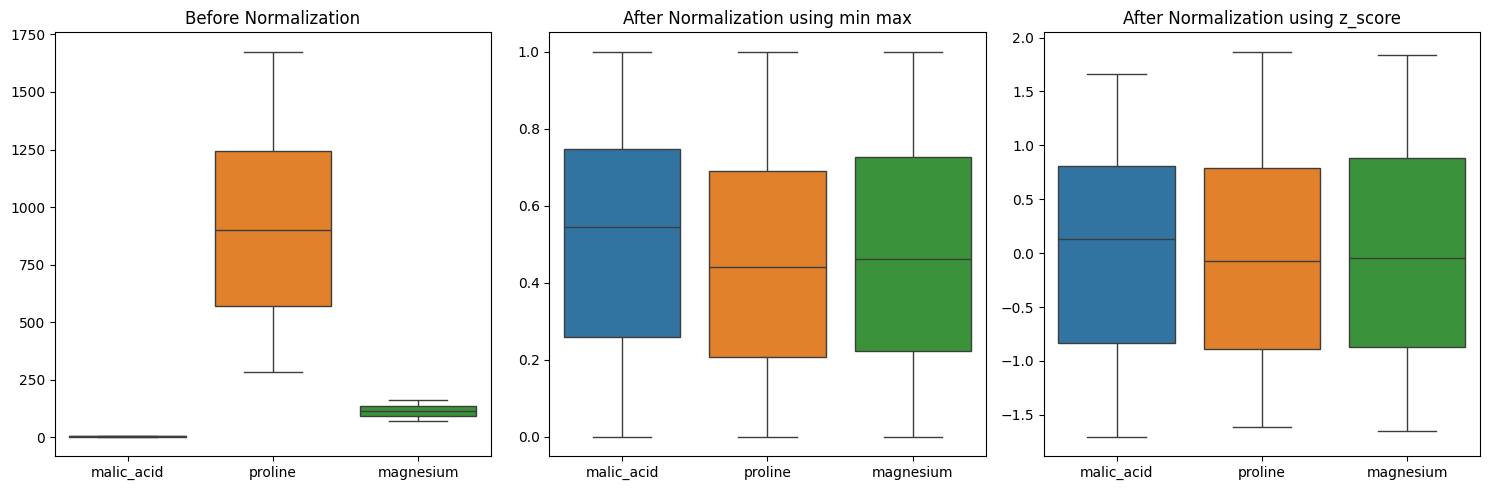

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('1_Normalization_Wine.csv')
print(df)

print('-------------------------------------------------------------------------------------------------')

#min max scaling

normalize_data = df.copy()

for data in ['malic_acid','proline','magnesium']:
  min_val = df[data].min()
  max_val = df[data].max()
  normalize_data[data] = (df[data] - min_val) / (max_val - min_val)

print('\nNormalized dataset\n:',normalize_data)


print('-------------------------------------------------------------------------------------------------')

#z score standarization

z_score = df.copy()

for z in ['malic_acid','proline','magnesium']:
  z_mean = df[z].mean()
  z_std = df[z].std()
  z_score[z] = (df[z] - z_mean) / (z_std)

print('\n this is z_score standarization')
print(z_score.head())

print('-------------------------------------------------------------------------------------------------')

#Visualize

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df[['malic_acid', 'proline', 'magnesium']], ax=axes[0])
axes[0].set_title('Before Normalization')

sns.boxplot(data=normalize_data[['malic_acid', 'proline', 'magnesium']], ax=axes[1])
axes[1].set_title('After Normalization using min max')

sns.boxplot(data=z_score[['malic_acid', 'proline', 'magnesium']], ax=axes[2])
axes[2].set_title('After Normalization using z_score')

plt.tight_layout()
plt.show()

# **2.Binarization**

     survived  pclass     sex  age    fare
0           0       1  female   16    1.37
1           0       3  female   43  110.64
2           0       3    male    8   51.30
3           0       2    male   36   11.09
4           1       3    male   60  125.14
..        ...     ...     ...  ...     ...
195         0       3    male   10   26.28
196         1       2    male   49   88.38
197         0       1    male   62    1.72
198         1       2    male   51   17.36
199         0       2    male   42    9.64

[200 rows x 5 columns]
     survived  pclass     sex  age    fare  adult  bn_fare
0           0       1  female   16    1.37      0      0.0
1           0       3  female   43  110.64      1      1.0
2           0       3    male    8   51.30      0      1.0
3           0       2    male   36   11.09      1      0.0
4           1       3    male   60  125.14      1      1.0
..        ...     ...     ...  ...     ...    ...      ...
195         0       3    male   10   26.28     

/tmp/ipykernel_2438/3675782449.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['adult'], ax=axes[0,1], palette='Dark2')
/tmp/ipykernel_2438/3675782449.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['bn_fare'], ax=axes[1,1], palette='PRGn')


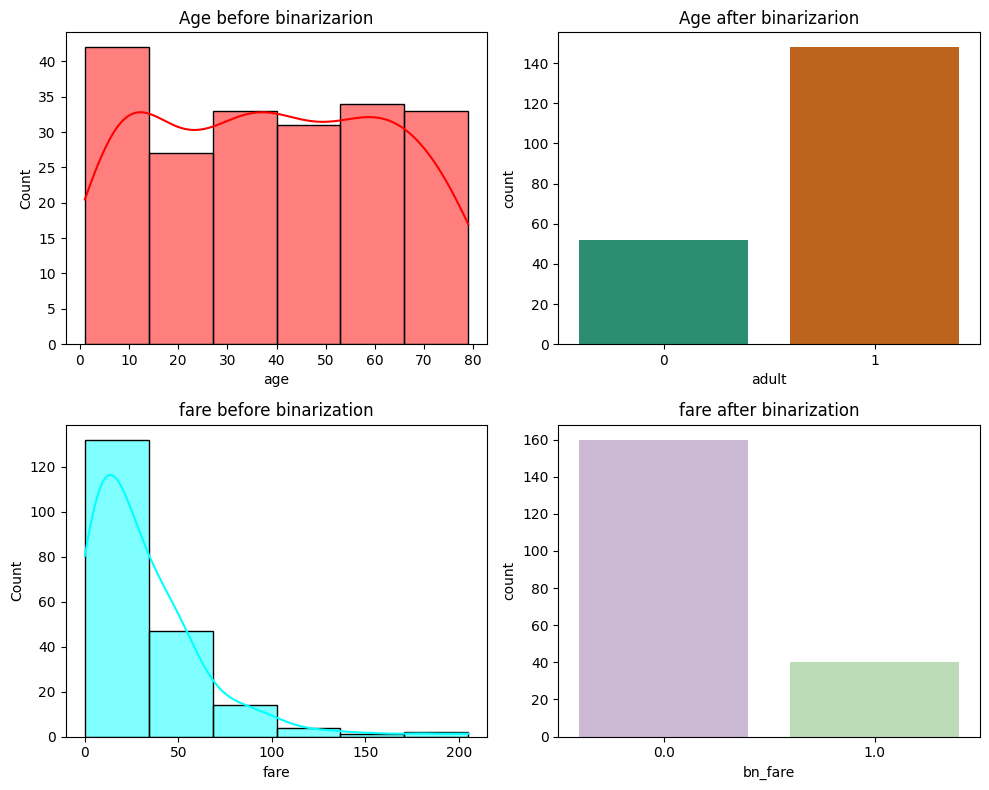

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import Binarizer


df =pd.read_csv('2_Binarization_Titanic.csv')
df['age'] = df['age'].astype(int)
print(df)

bn_Age=Binarizer(threshold=18)
bn_fare= Binarizer(threshold=50)

df['adult'] = bn_Age.fit_transform(df[['age']])
df['bn_fare'] = bn_fare.fit_transform(df[['fare']])

print(df)
print('-------------------------------------------------------------------------------------------------')



fig, axes = plt.subplots(2,2, figsize=(10,8))

sns.histplot(df['age'], bins=6, ax=axes[0,0], kde=True, color='red')
axes[0,0].set_title('Age before binarizarion')

sns.countplot(x=df['adult'], ax=axes[0,1], palette='Dark2')
axes[0,1].set_title('Age after binarizarion')

sns.histplot(df['fare'], bins=6, ax=axes[1,0], kde=True, color='cyan')
axes[1,0].set_title('fare before binarization')

sns.countplot(x=df['bn_fare'], ax=axes[1,1], palette='PRGn')
axes[1,1].set_title('fare after binarization')

plt.tight_layout()
plt.show()

# **3.One-Hot Encoding and label encoding**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

df =pd.read_csv('3_Encoding_Tips.csv')
print(df)
print('-------------------------------------------------------------------------------------------------')


#one hot encoding
df_onehot =pd.get_dummies(df, columns=['day','sex','smoker'])
print(df_onehot)
print('-------------------------------------------------------------------------------------------------')

#label encoding

le = LabelEncoder()

df['lable_time'] = le.fit_transform(df['time'])

df['lable_day'] = le.fit_transform(df['day'])

print(df.head(20))
print('-------------------------------------------------------------------------------------------------')


     total_bill   tip     sex smoker   day    time
0         37.89  3.71    Male     No  Thur   Lunch
1         49.16  6.39    Male     No  Thur   Lunch
2         16.54  3.68  Female    Yes   Fri   Lunch
3         34.44  3.70  Female     No   Sat  Dinner
4         13.91  7.69    Male    Yes   Fri  Dinner
..          ...   ...     ...    ...   ...     ...
195       29.33  1.21  Female     No  Thur  Dinner
196        9.34  7.81  Female     No   Fri  Dinner
197       15.89  5.13    Male     No   Sat   Lunch
198        5.56  3.60  Female     No   Sun  Dinner
199       26.09  9.10    Male    Yes   Sun  Dinner

[200 rows x 6 columns]
-------------------------------------------------------------------------------------------------
     total_bill   tip    time  day_Fri  day_Sat  day_Sun  day_Thur  \
0         37.89  3.71   Lunch    False    False    False      True   
1         49.16  6.39   Lunch    False    False    False      True   
2         16.54  3.68   Lunch     True    False    False

# 4.**Imputation**

In [ ]:
from numpy import median
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

df = pd.read_csv('4_Imputation_Titanic.csv')
print(df)

mean_imputer = SimpleImputer(strategy='mean')
df['mean_age']= mean_imputer.fit_transform(df[['age']])

mode_imputer = SimpleImputer(strategy='most_frequent')
df['mode_age']= mode_imputer.fit_transform(df[['age']])

median_imputer = SimpleImputer(strategy='median')
df['median_age']= median_imputer.fit_transform(df[['age']])
print(df)





     survived  pclass     sex   age embarked
0           0       2  female  64.7        C
1           1       3    male  78.8        C
2           0       2    male  60.6        C
3           0       3  female  32.1        S
4           0       1  female  47.7        C
..        ...     ...     ...   ...      ...
195         1       2  female   NaN        S
196         0       2    male   NaN        S
197         1       1  female  37.3        S
198         1       1  female   NaN        S
199         0       2  female   NaN        Q

[200 rows x 5 columns]
     survived  pclass     sex   age embarked   mean_age  mode_age  median_age
0           0       2  female  64.7        C  64.700000      64.7        64.7
1           1       3    male  78.8        C  78.800000      78.8        78.8
2           0       2    male  60.6        C  60.600000      60.6        60.6
3           0       3  female  32.1        S  32.100000      32.1        32.1
4           0       1  female  47.7        C  

# 5.**Winsorization**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.0 MB/s eta 0:00:00
      MedInc  HouseAge  AveRooms  Population  MedHouseValue
0     2.1529        30      5.44        1173       433818.0
1    12.5766        18      5.41        4913       102121.0
2    12.6556        24      3.88        3669       367681.0
3     9.4380         9      4.16        3250       276660.0
4     6.2669        31      4.04        1705       423119.0
..       ...       ...       ...         ...            ...
195   7.2577        31      4.37        4018       104637.0
196   9.8082        17      7.03        1167       374510.0
197   2.6013        24      6.20         126       132703.0
198   2.6851        23      5.46         647       197774.0
199   3.8197        18      6.16        2768       269246.0

[200 rows x 5 columns]


Text(0.5, 1.0, 'after the winsorization')

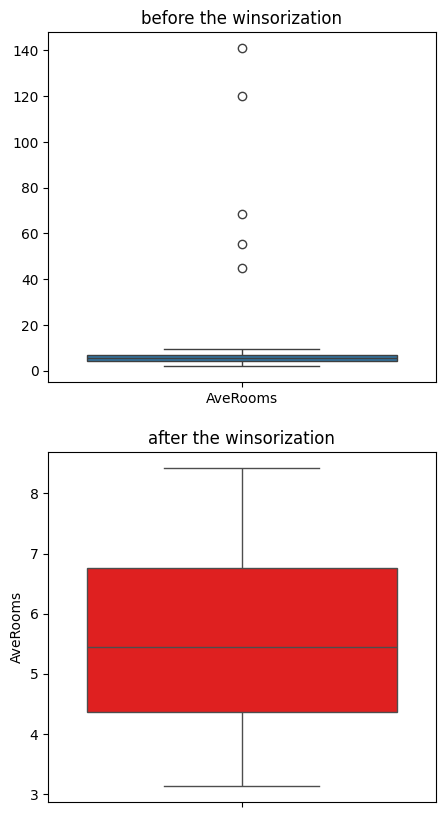

In [ ]:
#Winsorization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install feature-engine
from feature_engine.outliers import Winsorizer

df=pd.read_csv("5_Winsorization_CaliforniaHousing.csv")
print(pd.DataFrame(df))


fig, axes =plt.subplots(2,1, figsize=(5,10))
sns.boxplot(df[['AveRooms']],ax=axes[0])
axes[0].set_title('before the winsorization')


win = Winsorizer(capping_method='quantiles', tail='both', fold=0.05, variables=['AveRooms'])
win_data = win.fit_transform(df[['AveRooms']])



sns.boxplot(win_data.AveRooms,color='red',ax=axes[1])
axes[1].set_title('after the winsorization')
